Number of samples : 1000
Sample rate       : 100000 Hz
Duration           : 10.00 ms
Start frequency    : 1000 Hz
End frequency      : 10000 Hz


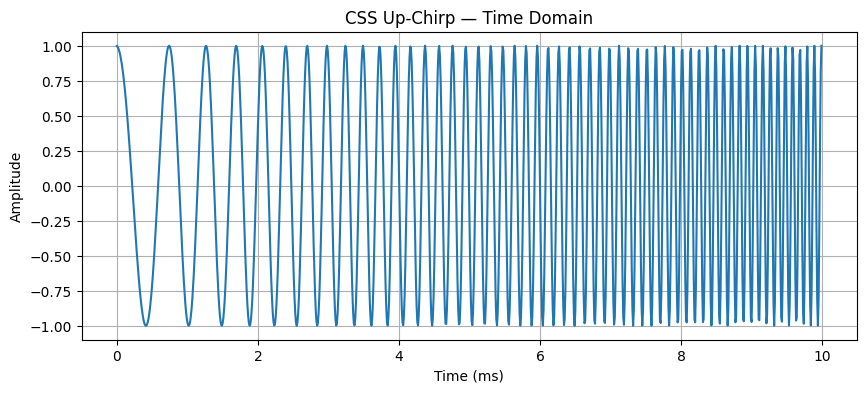

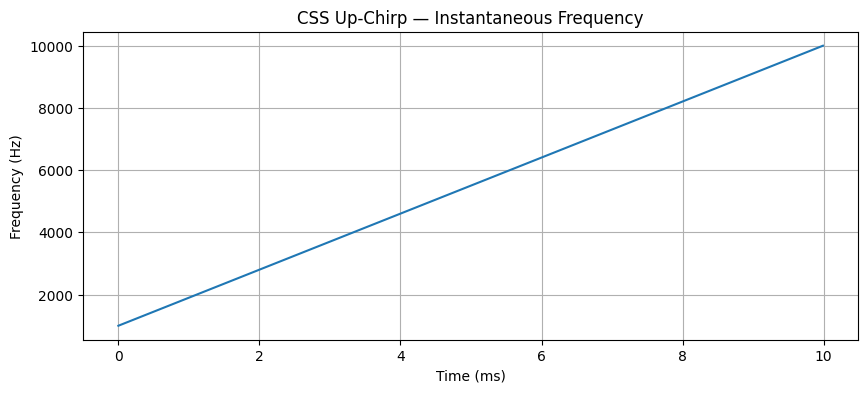

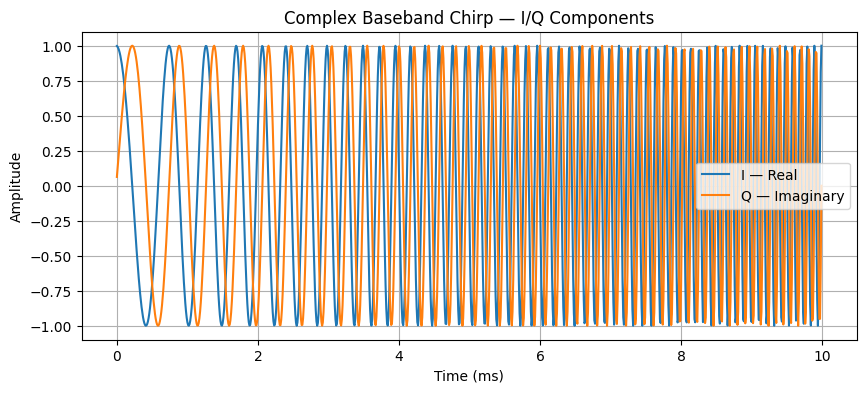

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LORA-02 — CSS Chirp Visualization
# ============================================================

# Parameters
sample_rate = 100_000       # samples per second
duration = 0.01             # 10 ms

start_frequency = 1_000     # 1 kHz
end_frequency = 10_000      # 10 kHz

# ------------------------------------------------------------
# 1. Create time vector
# ------------------------------------------------------------

t = np.arange(
    0,
    duration,
    1 / sample_rate
)

# ------------------------------------------------------------
# 2. Create instantaneous-frequency vector
# ------------------------------------------------------------

frequency = np.linspace(
    start_frequency,
    end_frequency,
    len(t)
)

# ------------------------------------------------------------
# 3. Integrate frequency -> phase
# ------------------------------------------------------------

phase = (
    2
    * np.pi
    * np.cumsum(frequency)
    / sample_rate
)

# ------------------------------------------------------------
# 4. Generate complex baseband chirp
# ------------------------------------------------------------

chirp = np.exp(1j * phase)

# ------------------------------------------------------------
# 5. Print basic information
# ------------------------------------------------------------

print(f"Number of samples : {len(chirp)}")
print(f"Sample rate       : {sample_rate} Hz")
print(f"Duration           : {duration * 1000:.2f} ms")
print(f"Start frequency    : {start_frequency} Hz")
print(f"End frequency      : {end_frequency} Hz")

# ============================================================
# Plot 1 — Time-domain chirp
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t * 1000,
    np.real(chirp)
)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("CSS Up-Chirp — Time Domain")
plt.grid()
plt.show()

# ============================================================
# Plot 2 — Instantaneous frequency
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t * 1000,
    frequency
)

plt.xlabel("Time (ms)")
plt.ylabel("Frequency (Hz)")
plt.title("CSS Up-Chirp — Instantaneous Frequency")
plt.grid()
plt.show()

# ============================================================
# Plot 3 — Real and imaginary components
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t * 1000,
    np.real(chirp),
    label="I — Real"
)

plt.plot(
    t * 1000,
    np.imag(chirp),
    label="Q — Imaginary"
)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Complex Baseband Chirp — I/Q Components")
plt.legend()
plt.grid()
plt.show()